In [1]:
from pc_training import TracePCTrainConfig, PCInferenceConfig, train_trace_model, evaluate_trace_model
import seaborn as sns
import matplotlib.pyplot as plt
from dataloader import TraceDataset

In [ ]:
inference = PCInferenceConfig(
    n_steps=5,
    step_size=0.1,
    until_converged=True,
    convergence_tol=1e-3,
    max_steps=400,
    min_steps=3,
)
config = TracePCTrainConfig(
    test_split=0,
    epochs=200,
    noise=0.1,
    steps_per_phoneme=5,
    inference=inference,
    clamp_output_at_last_step=True,
    early_stop_on_train_acc=True,
    learning_rate=1e-2
)
result = train_trace_model(config=config)
model = result.model
history = result.history
train_dataloader = result.train_dataloader
val_dataloader = result.val_dataloader

free_energy = history["free_energy"]
gradients = history["grad_norm"]
accuracies = history["acc"]
val_accuracies = history["val_acc"]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 186/200 F: 51.7888 Acc: 0.00, Val 0.00%:  92%|█████████▎| 185/200 [00:16<00:01, 10.95it/s]

## Training on TRACE (Predictive Coding)


In [ ]:
inference = PCInferenceConfig(n_steps=5, step_size=0.2)
config = TracePCTrainConfig(
    test_split=0,
    epochs=400,
    noise=0.0,
    steps_per_phoneme=20,
    inference=inference,
    clamp_output_at_last_step=True,
    early_stop_on_train_acc=True,
)
result = train_trace_model(config=config)
model = result.model
history = result.history
train_dataloader = result.train_dataloader
val_dataloader = result.val_dataloader

free_energy = history["free_energy"]
gradients = history["grad_norm"]
accuracies = history["acc"]
val_accuracies = history["val_acc"]


Epoch 198/400 F: 41.2963 Acc: 0.00, Val 0.00%:  50%|████▉     | 198/400 [01:06<01:31,  2.21it/s]

KeyboardInterrupt: 

## Plot the history

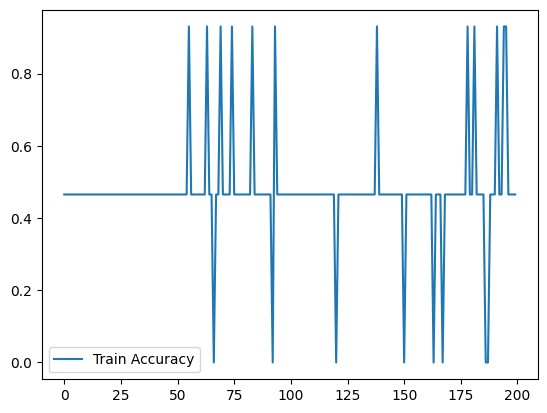

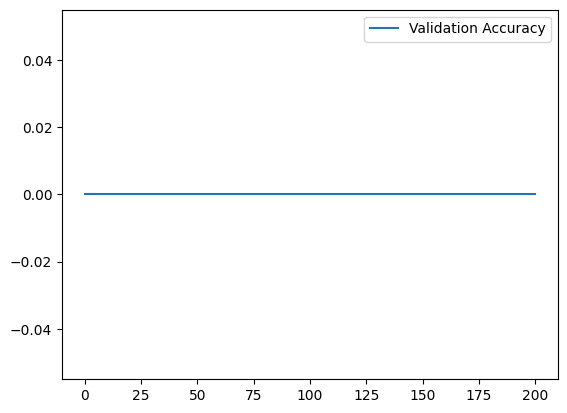

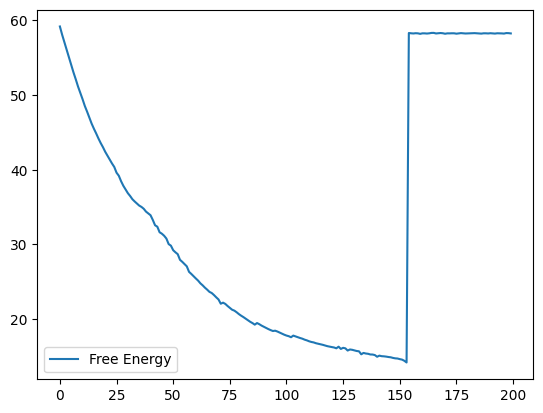

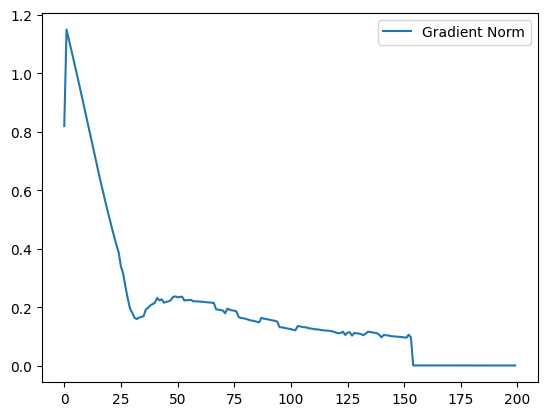

In [3]:
sns.lineplot(accuracies, label='Train Accuracy')
plt.show()
sns.lineplot(val_accuracies, label='Validation Accuracy')
plt.show()
sns.lineplot(free_energy, label='Free Energy')
plt.show()
sns.lineplot(gradients, label='Gradient Norm')
plt.show()


In [31]:
acc, predictions, original_words = evaluate_trace_model(model, train_dataloader, config)


In [32]:
for p, w in zip(predictions, original_words):
    pred_w = TraceDataset().words_padded[p.item()]
    if pred_w[:len(w)] != w:
        print(f"Predicted: {pred_w}, Original: {w}")


Predicted: kar------, Original: tru
Predicted: ^d^lt----, Original: tr^st
Predicted: partli---, Original: s^ksid
Predicted: partli---, Original: du
Predicted: lus------, Original: klak
Predicted: partli---, Original: slip
Predicted: Sat------, Original: badi
Predicted: stil-----, Original: k^p
Predicted: trat-----, Original: ^
Predicted: lus------, Original: klu
Predicted: prist----, Original: dal
Predicted: prist----, Original: art
Predicted: prist----, Original: rid
Predicted: stil-----, Original: kru^l
Predicted: ^d^lt----, Original: brid
Predicted: kar------, Original: tul
Predicted: partli---, Original: plat
Predicted: prist----, Original: lig
Predicted: stil-----, Original: did
Predicted: trat-----, Original: Sarp
Predicted: prist----, Original: trup
Predicted: kar------, Original: gad
Predicted: lus------, Original: start
Predicted: partli---, Original: kard
Predicted: partli---, Original: pik
Predicted: kar------, Original: strik
Predicted: trat-----, Original: kruS^l
Predicted

## Simple inference visualization


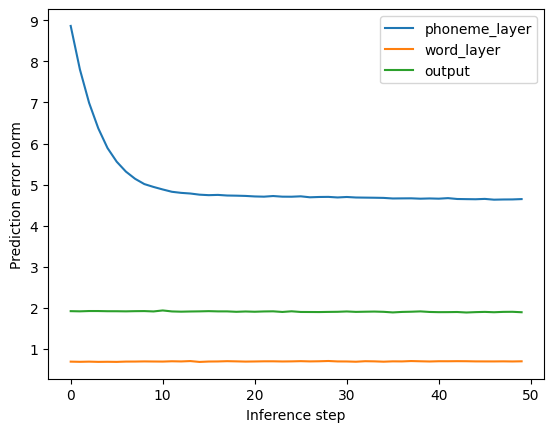

In [33]:
def pc_viz(model, input_vec, n_steps=50, step_size=0.05):
    model.eval()
    model.reset()
    model.release_clamp()

    if input_vec.ndim == 1:
        input_vec = input_vec.unsqueeze(0)
    model.layers[0].clamp(input_vec)

    layer_names = list(model.layers._modules.keys())
    errors = {name: [] for name in layer_names[1:]}

    for _ in range(n_steps):
        model.infer(n_steps=1, step_size=step_size)
        for idx in range(1, len(model.layers)):
            upper = model.layers[idx]
            lower = model.layers[idx - 1]
            prediction = upper.predict_down()
            error = (lower.state - prediction).detach()
            err_norm = error.norm(dim=tuple(range(1, error.ndim))).mean().item()
            errors[layer_names[idx]].append(err_norm)

    for name, vals in errors.items():
        plt.plot(vals, label=name)
    plt.xlabel('Inference step')
    plt.ylabel('Prediction error norm')
    plt.legend()
    plt.show()

device = model.device
words, features, labels_ind = next(iter(train_dataloader)).values()
features = features.to(device)

pc_viz(model, features[0, 0], n_steps=50, step_size=0.05)
